# 06 Leave-one-user-out dla `event_threshold_10`

Celem notebooka jest sprawdzenie, czy pierwsze modele z notebooka 05 generalizują między użytkownikami.

Notebook 05 odpowiadał na pytanie: czy model działa na późniejszym fragmencie czasu tych samych użytkowników. Notebook 06 odpowiada na trudniejsze pytanie: czy model wytrenowany na części użytkowników działa na całkiem innym użytkowniku.

To jest ważne metodologicznie, bo BWCI jest proxy behawioralnym normalizowanym per user. Jeżeli model działa tylko w obrębie tych samych użytkowników, w pracy trzeba to wyraźnie oddzielić od generalizacji międzyosobniczej.


In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT_CANDIDATES: list[Path] = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if (path / "AGENTS.md").exists()), Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATASET_PATH = OUTPUT_DIR / "model_dataset_event_threshold_10_v0_1.parquet"
METADATA_PATH = OUTPUT_DIR / "model_dataset_event_threshold_10_v0_1_metadata.json"
LOGO_RESULTS_PATH = OUTPUT_DIR / "logo_results_event_threshold_10_v0_1.csv"
LOGO_SUMMARY_PATH = OUTPUT_DIR / "logo_summary_event_threshold_10_v0_1.csv"
LOGO_PREDICTIONS_PATH = OUTPUT_DIR / "logo_predictions_event_threshold_10_v0_1.parquet"

RANDOM_STATE = 42
THRESHOLD = 0.50

sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## Sekcja 1: Dane i rozkład targetu per użytkownik

Wczytujemy ten sam dataset modelowy co w notebooku 05. Najpierw sprawdzamy rozkład `event_threshold_10` per użytkownik, bo leave-one-user-out jest bardzo wrażliwe na użytkowników bez klasy pozytywnej.


In [2]:
if not DATASET_PATH.exists():
  raise FileNotFoundError(f"Missing model dataset: {DATASET_PATH}")
if not METADATA_PATH.exists():
  raise FileNotFoundError(f"Missing model metadata: {METADATA_PATH}")

model_dataset = pd.read_parquet(DATASET_PATH)
metadata = json.loads(METADATA_PATH.read_text())
TARGET_COL = str(metadata["classification_target"])
feature_sets: dict[str, list[str]] = metadata["feature_sets"]

load_summary = pd.DataFrame(
  [
    {
      "rows": len(model_dataset),
      "users": model_dataset["USER"].nunique(),
      "target": TARGET_COL,
      "positive_rows": int(model_dataset[TARGET_COL].sum()),
      "positive_pct": model_dataset[TARGET_COL].mean() * 100,
    }
  ]
)
load_summary


,rows,users,target,positive_rows,positive_pct
0,76039,11,event_threshold_10,15637,20.5644


In [3]:
user_target_summary = (
  model_dataset.groupby("USER")
  .agg(
    rows=(TARGET_COL, "size"),
    positive_rows=(TARGET_COL, "sum"),
    positive_pct=(TARGET_COL, lambda values: values.mean() * 100),
    start=("datetime", "min"),
    end=("datetime", "max"),
  )
  .reset_index()
)
user_target_summary


,USER,rows,positive_rows,positive_pct,start,end
0,0,5311,1328,25.0047,2019-11-20 13:48:20.304,2020-01-11 17:56:54.223
1,1,13450,2,0.0149,2019-12-04 22:13:01.785,2020-01-14 09:31:25.916
2,3,3136,782,24.9362,2019-12-09 14:53:22.760,2020-01-13 22:45:20.130
3,4,8110,2030,25.0308,2019-11-26 11:38:02.721,2020-01-14 09:03:05.426
4,5,1722,433,25.1452,2019-12-02 20:55:51.796,2019-12-05 23:29:48.556
5,6,982,248,25.2546,2019-12-18 21:44:51.449,2020-01-14 01:00:35.230
6,7,3557,883,24.8243,2019-12-04 08:58:00.932,2020-01-14 09:00:20.863
7,8,4280,1066,24.9065,2019-11-20 12:09:14.895,2020-01-13 17:06:54.138
8,9,5745,1436,24.9956,2019-11-20 14:34:28.657,2019-12-15 22:02:09.117
9,10,12921,3223,24.9439,2019-11-20 16:59:44.595,2020-01-14 09:43:19.013


### Interpretacja targetu per user

Większość użytkowników ma około 25% pozytywnych przypadków, co wynika z definicji progu jako dolnego kwartylu per użytkownik. User 1 jest wyjątkiem: ma praktycznie brak pozytywnej klasy.

To oznacza, że AUC-ROC i AUC-PR dla folda z User 1 jako testem będą niezdefiniowane lub mało użyteczne. Nie należy tego ukrywać przez imputowanie metryk; taki fold pokazuje ograniczenie targetu `event_threshold_10` dla użytkowników o specyficznym rozkładzie BWCI.


## Sekcja 2: Modele do LOGO

Używamy tych samych rodzin modeli co w notebooku 05, ale każdy model jest trenowany od nowa dla każdego testowego użytkownika.

Główne porównanie pozostaje takie samo:

- `dummy_prior`,
- `autoregressive_lr`,
- `behavior_logistic_lr`,
- `behavior_random_forest`,
- `behavior_hist_gradient_boosting`,
- `behavior_plus_bwci_lr` jako wariant diagnostyczny.


In [4]:
def make_scaled_logistic_pipeline(class_weight: str | None = "balanced") -> Pipeline:
  """ Create a median-imputed, scaled logistic regression pipeline.

    Args:
      class_weight: Class weighting strategy passed to LogisticRegression.

    Returns:
      Pipeline: Scikit-learn logistic regression pipeline.
  """
  return Pipeline(
    steps=[
      ("imputer", SimpleImputer(strategy="median")),
      ("scaler", StandardScaler()),
      (
        "model",
        LogisticRegression(
          max_iter=1000,
          class_weight=class_weight,
          random_state=RANDOM_STATE,
          solver="lbfgs",
        ),
      ),
    ]
  )


def make_tree_imputer_pipeline(model: BaseEstimator) -> Pipeline:
  """ Create a median-imputed tree-model pipeline.

    Args:
      model: Scikit-learn tree-based classifier.

    Returns:
      Pipeline: Pipeline with median imputation and a classifier.
  """
  return Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("model", model)])


models: dict[str, tuple[BaseEstimator, list[str], str]] = {
  "dummy_prior": (DummyClassifier(strategy="prior"), feature_sets["baseline_autoregressive"], "baseline"),
  "autoregressive_lr": (make_scaled_logistic_pipeline(), feature_sets["baseline_autoregressive"], "baseline"),
  "behavior_logistic_lr": (make_scaled_logistic_pipeline(), feature_sets["behavior_primary"], "primary"),
  "behavior_random_forest": (
    make_tree_imputer_pipeline(
      RandomForestClassifier(
        n_estimators=100,
        min_samples_leaf=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
      )
    ),
    feature_sets["behavior_primary"],
    "primary",
  ),
  "behavior_hist_gradient_boosting": (
    make_tree_imputer_pipeline(
      HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.06,
        l2_regularization=0.05,
        random_state=RANDOM_STATE,
      )
    ),
    feature_sets["behavior_primary"],
    "primary",
  ),
  "behavior_plus_bwci_lr": (make_scaled_logistic_pipeline(), feature_sets["behavior_plus_bwci"], "diagnostic"),
}

model_table = pd.DataFrame(
  [
    {"model": name, "feature_count": len(features), "model_group": group}
    for name, (_, features, group) in models.items()
  ]
)
model_table


,model,feature_count,model_group
0,dummy_prior,1,baseline
1,autoregressive_lr,1,baseline
2,behavior_logistic_lr,21,primary
3,behavior_random_forest,21,primary
4,behavior_hist_gradient_boosting,21,primary
5,behavior_plus_bwci_lr,22,diagnostic


## Sekcja 3: Funkcje ewaluacji

Metryki liczymy ostrożnie: jeśli testowy użytkownik ma tylko jedną klasę, AUC-ROC i AUC-PR są ustawiane na `NaN`. To jest poprawniejsze niż wymuszanie liczby, która wyglądałaby jak wynik modelu.


In [5]:
def get_xy(df: pd.DataFrame, features: list[str]) -> tuple[pd.DataFrame, pd.Series]:
  """ Extract feature matrix and binary target vector.

    Args:
      df: Modeling dataset.
      features: Feature column names.

    Returns:
      tuple[pd.DataFrame, pd.Series]: Feature matrix and target vector.
  """
  return df[features], df[TARGET_COL].astype(int)


def predict_positive_probability(model: BaseEstimator, x_values: pd.DataFrame) -> np.ndarray:
  """ Predict positive-class probability from a fitted classifier.

    Args:
      model: Fitted scikit-learn classifier.
      x_values: Feature matrix.

    Returns:
      np.ndarray: Positive-class probabilities.
  """
  if hasattr(model, "predict_proba"):
    return model.predict_proba(x_values)[:, 1]
  decision = model.decision_function(x_values)
  return 1.0 / (1.0 + np.exp(-decision))


def score_predictions(y_true: pd.Series, y_proba: np.ndarray, threshold: float = THRESHOLD) -> dict[str, float]:
  """ Compute metrics for one binary classification evaluation.

    Args:
      y_true: Ground-truth binary labels.
      y_proba: Positive-class probabilities.
      threshold: Probability threshold for class predictions.

    Returns:
      dict[str, float]: Metric dictionary.
  """
  y_true_arr = np.asarray(y_true).astype(int)
  y_pred = (y_proba >= threshold).astype(int)
  unique_classes = np.unique(y_true_arr)

  tp = int(((y_true_arr == 1) & (y_pred == 1)).sum())
  fp = int(((y_true_arr == 0) & (y_pred == 1)).sum())
  tn = int(((y_true_arr == 0) & (y_pred == 0)).sum())
  fn = int(((y_true_arr == 1) & (y_pred == 0)).sum())

  precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
  recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
  specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
  f1 = 2 * precision * recall / (precision + recall) if pd.notna(recall) and (precision + recall) > 0 else np.nan
  balanced = np.nanmean([recall, specificity]) if len(unique_classes) == 2 else np.nan

  return {
    "roc_auc": roc_auc_score(y_true_arr, y_proba) if len(unique_classes) == 2 else np.nan,
    "auc_pr": average_precision_score(y_true_arr, y_proba) if len(unique_classes) == 2 else np.nan,
    "brier": brier_score_loss(y_true_arr, y_proba),
    "balanced_accuracy": balanced,
    "precision_pos": precision,
    "recall_pos": recall,
    "f1_pos": f1,
    "predicted_positive_pct": y_pred.mean() * 100,
  }


def evaluate_logo_fold(model_name: str, model: BaseEstimator, features: list[str], group: str, test_user: int) -> tuple[dict[str, object], pd.DataFrame]:
  """ Train one model on all users except test_user and evaluate on test_user.

    Args:
      model_name: Model identifier.
      model: Unfitted classifier.
      features: Feature columns.
      group: Model group label.
      test_user: Held-out user id.

    Returns:
      tuple[dict[str, object], pd.DataFrame]: Fold metrics and row-level predictions.
  """
  train_df = model_dataset[model_dataset["USER"] != test_user]
  test_df = model_dataset[model_dataset["USER"] == test_user]
  fitted = clone(model)
  x_train, y_train = get_xy(train_df, features)
  x_test, y_test = get_xy(test_df, features)
  fitted.fit(x_train, y_train)
  y_proba = predict_positive_probability(fitted, x_test)
  metrics = score_predictions(y_test, y_proba)

  prediction_df = test_df[["USER", "obs_idx", "datetime", TARGET_COL]].copy()
  prediction_df["model"] = model_name
  prediction_df["model_group"] = group
  prediction_df["y_proba"] = y_proba
  prediction_df["y_pred"] = (y_proba >= THRESHOLD).astype(int)

  row = {
    "model": model_name,
    "model_group": group,
    "test_user": int(test_user),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "test_positive_rows": int(y_test.sum()),
    "test_positive_pct": y_test.mean() * 100,
    **metrics,
  }
  return row, prediction_df


## Sekcja 4: Wykonanie leave-one-user-out

Każdy użytkownik jest kolejno odkładany jako test, a model jest trenowany na pozostałych użytkownikach. To sprawia, że wynik jest znacznie trudniejszy niż temporal split z notebooka 05.


In [6]:
logo_rows: list[dict[str, object]] = []
prediction_frames: list[pd.DataFrame] = []
users = sorted(model_dataset["USER"].unique())

for test_user in users:
  for model_name, (model, features, group) in models.items():
    row, prediction_df = evaluate_logo_fold(model_name, model, features, group, int(test_user))
    logo_rows.append(row)
    prediction_frames.append(prediction_df)

logo_results = pd.DataFrame(logo_rows)
logo_predictions = pd.concat(prediction_frames, ignore_index=True)
logo_results.sort_values(["test_user", "auc_pr"], ascending=[True, False]).head(30)


,model,model_group,test_user,train_rows,test_rows,test_positive_rows,test_positive_pct,roc_auc,auc_pr,brier,balanced_accuracy,precision_pos,recall_pos,f1_pos,predicted_positive_pct
4,behavior_hist_gradient_boosting,primary,0,70728,5311,1328,25.0047,0.6641,0.4015,0.1764,0.5206,0.6442,0.0505,0.0936,1.9582
1,autoregressive_lr,baseline,0,70728,5311,1328,25.0047,0.6625,0.3712,0.2313,0.6172,0.3495,0.6175,0.4464,44.1725
2,behavior_logistic_lr,primary,0,70728,5311,1328,25.0047,0.6531,0.3675,0.3490,0.5393,0.2663,0.9684,0.4177,90.9433
5,behavior_plus_bwci_lr,diagnostic,0,70728,5311,1328,25.0047,0.6536,0.3595,0.3498,0.5502,0.2716,0.9503,0.4224,87.4976
3,behavior_random_forest,primary,0,70728,5311,1328,25.0047,0.6383,0.3538,0.2333,0.6002,0.3325,0.6062,0.4294,45.5846
0,dummy_prior,baseline,0,70728,5311,1328,25.0047,0.5000,0.2500,0.1898,0.5000,0.0000,0.0000,NaN,0.0000
11,behavior_plus_bwci_lr,diagnostic,1,62589,13450,2,0.0149,0.5225,0.0004,0.0745,0.4840,0.0000,0.0000,NaN,3.1896
8,behavior_logistic_lr,primary,1,62589,13450,2,0.0149,0.4560,0.0003,0.1114,0.4678,0.0000,0.0000,NaN,6.4312
10,behavior_hist_gradient_boosting,primary,1,62589,13450,2,0.0149,0.4334,0.0003,0.1073,0.4752,0.0000,0.0000,NaN,4.9591
9,behavior_random_forest,primary,1,62589,13450,2,0.0149,0.3985,0.0002,0.3560,0.3415,0.0001,0.5000,0.0002,81.7026


### Interpretacja wyników foldów

Wyniki foldów pokazują dużą nierówność między użytkownikami. Dla najlepszego modelu primary w tym notebooku (`behavior_hist_gradient_boosting`) AUC-PR wynosi od `0.5544` dla User 6 do `0.2889` dla User 10, a dla User 1 spada praktycznie do zera (`0.0003`), bo User 1 ma tylko `2` pozytywne przypadki na `13,450` obserwacji.

To nie jest drobna fluktuacja metryki, tylko sygnał metodologiczny: target `event_threshold_10` zachowuje się inaczej dla User 1 niż dla reszty użytkowników. Fold z User 1 nie powinien być traktowany jako zwykła porażka modelu; pokazuje ograniczenie samej definicji targetu progowego.


## Sekcja 5: Podsumowanie modeli LOGO

Raportujemy trzy warianty agregacji:

- `macro_mean`: średnia po foldach z pominięciem `NaN`,
- `weighted_mean`: średnia ważona liczbą wierszy testowych, też z pominięciem `NaN`,
- `pooled`: metryka liczona po złączeniu wszystkich predykcji out-of-fold.

Pooled wynik może być zdominowany przez dużych użytkowników. Macro pokazuje typowy fold użytkownika, ale ignoruje różnice wielkości próby.


In [7]:
def weighted_nanmean(values: pd.Series, weights: pd.Series) -> float:
  """ Compute a weighted mean while ignoring NaN values.

    Args:
      values: Values to average.
      weights: Non-negative weights.

    Returns:
      float: Weighted mean or NaN if all values are missing.
  """
  valid = values.notna()
  if not valid.any():
    return np.nan
  return np.average(values[valid], weights=weights[valid])


def summarize_logo_results(results: pd.DataFrame, predictions: pd.DataFrame) -> pd.DataFrame:
  """ Summarize LOGO results by model.

    Args:
      results: Fold-level LOGO metrics.
      predictions: Row-level out-of-fold predictions.

    Returns:
      pd.DataFrame: Aggregated model summary.
  """
  rows: list[dict[str, object]] = []
  metric_cols = ["roc_auc", "auc_pr", "brier", "balanced_accuracy", "precision_pos", "recall_pos", "f1_pos"]
  for model_name, model_results in results.groupby("model"):
    model_predictions = predictions[predictions["model"] == model_name]
    y_true = model_predictions[TARGET_COL].astype(int)
    y_proba = model_predictions["y_proba"].to_numpy()
    pooled_metrics = score_predictions(y_true, y_proba)
    row: dict[str, object] = {
      "model": model_name,
      "model_group": model_results["model_group"].iloc[0],
      "folds": len(model_results),
      "valid_auc_folds": int(model_results["auc_pr"].notna().sum()),
      "pooled_positive_pct": y_true.mean() * 100,
    }
    for metric in metric_cols:
      row[f"{metric}_macro_mean"] = model_results[metric].mean(skipna=True)
      row[f"{metric}_weighted_mean"] = weighted_nanmean(model_results[metric], model_results["test_rows"])
      row[f"{metric}_pooled"] = pooled_metrics[metric]
    rows.append(row)
  return pd.DataFrame(rows)


logo_summary = summarize_logo_results(logo_results, logo_predictions)
logo_summary.sort_values("auc_pr_macro_mean", ascending=False)


,model,model_group,folds,valid_auc_folds,pooled_positive_pct,roc_auc_macro_mean,roc_auc_weighted_mean,roc_auc_pooled,auc_pr_macro_mean,auc_pr_weighted_mean,auc_pr_pooled,brier_macro_mean,brier_weighted_mean,brier_pooled,balanced_accuracy_macro_mean,balanced_accuracy_weighted_mean,balanced_accuracy_pooled,precision_pos_macro_mean,precision_pos_weighted_mean,precision_pos_pooled,recall_pos_macro_mean,recall_pos_weighted_mean,recall_pos_pooled,f1_pos_macro_mean,f1_pos_weighted_mean,f1_pos_pooled
0,autoregressive_lr,baseline,11,11,20.5644,0.6423,0.6199,0.6186,0.3411,0.2944,0.2723,0.2353,0.2397,0.2397,0.6076,0.5913,0.5989,0.3149,0.2790,0.2782,0.6103,0.5843,0.6025,0.4042,0.3569,0.3806
1,behavior_hist_gradient_boosting,primary,11,11,20.5644,0.6338,0.6024,0.5873,0.3358,0.2850,0.2490,0.1728,0.1690,0.1690,0.5045,0.4992,0.5006,0.3350,0.3051,0.2137,0.0246,0.0203,0.0247,0.0548,0.0467,0.0443
4,behavior_random_forest,primary,11,11,20.5644,0.6314,0.5983,0.5764,0.3355,0.2850,0.2472,0.2469,0.2618,0.2618,0.5817,0.5533,0.5582,0.3138,0.2753,0.2397,0.6359,0.6234,0.6499,0.3999,0.3568,0.3503
3,behavior_plus_bwci_lr,diagnostic,11,11,20.5644,0.6471,0.6255,0.7086,0.3327,0.2907,0.3363,0.2491,0.2325,0.2325,0.5963,0.5798,0.6576,0.2968,0.2665,0.3093,0.6909,0.6147,0.7468,0.4495,0.4442,0.4375
2,behavior_logistic_lr,primary,11,11,20.5644,0.6336,0.6077,0.6893,0.3258,0.2880,0.3217,0.2553,0.2401,0.2401,0.5834,0.5661,0.6429,0.2945,0.2690,0.2969,0.6898,0.6080,0.7386,0.4425,0.4375,0.4235
5,dummy_prior,baseline,11,11,20.5644,0.5000,0.5000,0.3887,0.2273,0.2056,0.1650,0.1783,0.1675,0.1675,0.5000,0.5000,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN


In [8]:
best_primary_logo = (
  logo_summary[logo_summary["model_group"] == "primary"]
  .sort_values("auc_pr_macro_mean", ascending=False)
  .iloc[0]
)
logo_metric_lookup = logo_summary.set_index("model")
logo_key_comparisons = pd.DataFrame(
  [
    {
      "comparison": "best_primary_vs_dummy_prior_auc_pr_macro",
      "best_primary_model": best_primary_logo["model"],
      "delta_auc_pr": best_primary_logo["auc_pr_macro_mean"] - logo_metric_lookup.loc["dummy_prior", "auc_pr_macro_mean"],
    },
    {
      "comparison": "best_primary_vs_autoregressive_auc_pr_macro",
      "best_primary_model": best_primary_logo["model"],
      "delta_auc_pr": best_primary_logo["auc_pr_macro_mean"] - logo_metric_lookup.loc["autoregressive_lr", "auc_pr_macro_mean"],
    },
    {
      "comparison": "best_primary_vs_behavior_plus_bwci_auc_pr_macro",
      "best_primary_model": best_primary_logo["model"],
      "delta_auc_pr": best_primary_logo["auc_pr_macro_mean"] - logo_metric_lookup.loc["behavior_plus_bwci_lr", "auc_pr_macro_mean"],
    },
  ]
)
logo_key_comparisons


,comparison,best_primary_model,delta_auc_pr
0,best_primary_vs_dummy_prior_auc_pr_macro,behavior_hist_gradient_boosting,0.1084
1,best_primary_vs_autoregressive_auc_pr_macro,behavior_hist_gradient_boosting,-0.0053
2,best_primary_vs_behavior_plus_bwci_auc_pr_macro,behavior_hist_gradient_boosting,0.0030


### Interpretacja agregacji LOGO

Agregacja LOGO jest wyraźnie bardziej konserwatywna niż temporal split. Najlepszy model primary według macro AUC-PR to `behavior_hist_gradient_boosting` z `0.3358`, ale baseline autoregresyjny `autoregressive_lr` ma `0.3411`. Różnica jest mała (`-0.0053` na niekorzyść najlepszego modelu primary), ale kierunek jest ważny: surowe cechy telemetryczne nie biją jednoznacznie bieżącego `BWCI_pu` przy generalizacji na nowego użytkownika.

Modele primary nadal wyraźnie biją `dummy_prior` (`0.3358` vs `0.2273` macro AUC-PR), więc sygnał istnieje. Nie jest jednak wystarczająco silny, żeby w LOGO uznać modele oparte wyłącznie na `behavior_primary` za lepsze od prostej autoregresji.

Warto też rozróżnić ranking i decyzje progowe. `behavior_hist_gradient_boosting` ma dobre macro AUC-PR, ale bardzo niski macro recall (`0.0246`), więc przy progu `0.50` prawie nie oznacza klasy pozytywnej. `behavior_random_forest` ma podobne macro AUC-PR (`0.3355`), ale dużo wyższy recall (`0.6359`), więc jest praktyczniejszy jako model alarmujący o ryzyku.


## Sekcja 6: Stabilność per użytkownik

Sprawdzamy, dla których użytkowników najlepszy model primary działa dobrze, a dla których wynik jest słaby albo niezdefiniowany.


In [9]:
best_primary_model = str(best_primary_logo["model"])
best_primary_folds = logo_results[logo_results["model"] == best_primary_model].sort_values("auc_pr", ascending=False)
best_primary_model, best_primary_folds


('behavior_hist_gradient_boosting',
                               model model_group  test_user  train_rows  \
 34  behavior_hist_gradient_boosting     primary          6       75057   
 28  behavior_hist_gradient_boosting     primary          5       74317   
 4   behavior_hist_gradient_boosting     primary          0       70728   
 64  behavior_hist_gradient_boosting     primary         11       59214   
 52  behavior_hist_gradient_boosting     primary          9       70294   
 40  behavior_hist_gradient_boosting     primary          7       72482   
 22  behavior_hist_gradient_boosting     primary          4       67929   
 46  behavior_hist_gradient_boosting     primary          8       71759   
 16  behavior_hist_gradient_boosting     primary          3       72903   
 58  behavior_hist_gradient_boosting     primary         10       63118   
 10  behavior_hist_gradient_boosting     primary          1       62589   
 
     test_rows  test_positive_rows  test_positive_pct  roc_auc

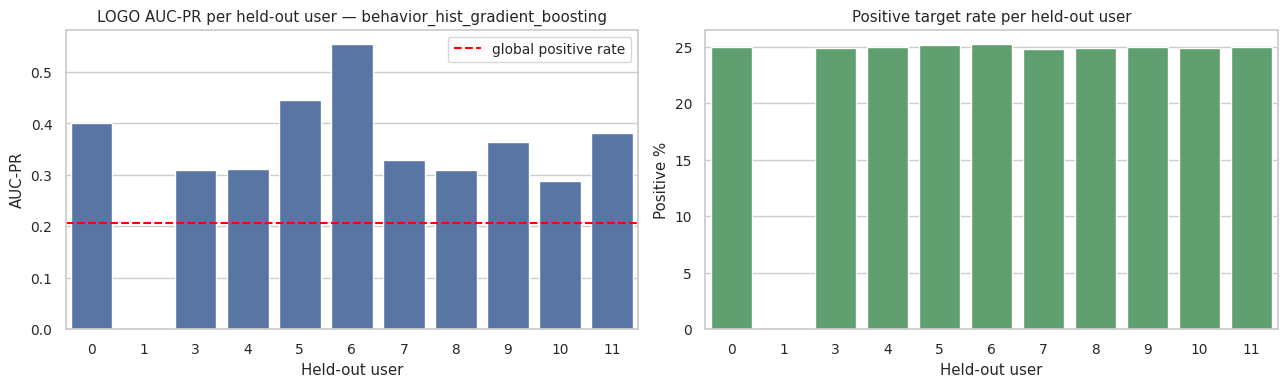

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_folds = best_primary_folds.copy()
sns.barplot(data=plot_folds, x="test_user", y="auc_pr", ax=axes[0], color="#4C72B0")
axes[0].axhline(model_dataset[TARGET_COL].mean(), color="red", linestyle="--", label="global positive rate")
axes[0].set_title(f"LOGO AUC-PR per held-out user: {best_primary_model}")
axes[0].set_xlabel("Held-out user")
axes[0].set_ylabel("AUC-PR")
axes[0].legend()

sns.barplot(data=plot_folds, x="test_user", y="test_positive_pct", ax=axes[1], color="#55A868")
axes[1].set_title("Positive target rate per held-out user")
axes[1].set_xlabel("Held-out user")
axes[1].set_ylabel("Positive %")
fig.tight_layout()
plt.show()


### Interpretacja stabilności

Dla najlepszego modelu primary (`behavior_hist_gradient_boosting`) rozrzut per user jest duży. User 6 ma AUC-PR `0.5544`, User 5 `0.4450`, User 0 `0.4015`, ale User 10 ma tylko `0.2889`, a User 1 `0.0003`. To pokazuje, że średnia macro ukrywa bardzo różne zachowanie modelu między użytkownikami.

Dodatkowo model ma bardzo niski recall dla większości użytkowników: np. User 11 `0.0252`, User 10 `0.0258`, User 9 `0.0056`. To oznacza, że przy domyślnym progu `0.50` ranking może być umiarkowanie użyteczny, ale klasyfikacja twarda jest zbyt zachowawcza. W przyszłym modelowaniu trzeba albo kalibrować próg, albo traktować prawdopodobieństwo/ranking jako główny output.

User 1 pozostaje osobnym problemem targetu: nie brakuje danych, bo ma `13,450` wierszy, ale brakuje pozytywnych zdarzeń. To bezpośrednio uzasadnia audyt targetu w następnym kroku.


## Sekcja 7: Porównanie z temporal split

Notebook 05 testował późniejsze fragmenty tych samych użytkowników. Tutaj porównujemy LOGO z tamtym wynikiem, jeśli plik wynikowy z notebooka 05 jest dostępny.


In [11]:
TEMPORAL_RESULTS_PATH = OUTPUT_DIR / "model_results_event_threshold_10_v0_1.csv"
if TEMPORAL_RESULTS_PATH.exists():
  temporal_results = pd.read_csv(TEMPORAL_RESULTS_PATH)
  temporal_test = temporal_results[temporal_results["split"] == "test"][["model", "auc_pr", "roc_auc", "brier"]].rename(
    columns={"auc_pr": "temporal_test_auc_pr", "roc_auc": "temporal_test_roc_auc", "brier": "temporal_test_brier"}
  )
  logo_compare = logo_summary[["model", "auc_pr_macro_mean", "auc_pr_pooled", "roc_auc_macro_mean", "roc_auc_pooled", "brier_macro_mean"]].merge(
    temporal_test,
    on="model",
    how="left",
  )
  logo_compare["auc_pr_macro_minus_temporal"] = logo_compare["auc_pr_macro_mean"] - logo_compare["temporal_test_auc_pr"]
else:
  logo_compare = pd.DataFrame()

logo_compare.sort_values("auc_pr_macro_mean", ascending=False)


,model,auc_pr_macro_mean,auc_pr_pooled,roc_auc_macro_mean,roc_auc_pooled,brier_macro_mean,temporal_test_auc_pr,temporal_test_roc_auc,temporal_test_brier,auc_pr_macro_minus_temporal
0,autoregressive_lr,0.3411,0.2723,0.6423,0.6186,0.2353,0.3321,0.6354,0.2382,0.0091
1,behavior_hist_gradient_boosting,0.3358,0.2490,0.6338,0.5873,0.1728,0.3976,0.7333,0.1591,-0.0619
4,behavior_random_forest,0.3355,0.2472,0.6314,0.5764,0.2469,0.4220,0.7477,0.2036,-0.0865
3,behavior_plus_bwci_lr,0.3327,0.3363,0.6471,0.7086,0.2491,0.4031,0.7313,0.2249,-0.0704
2,behavior_logistic_lr,0.3258,0.3217,0.6336,0.6893,0.2553,0.3861,0.7182,0.2317,-0.0603
5,dummy_prior,0.2273,0.1650,0.5000,0.3887,0.1783,0.2358,0.5000,0.1815,-0.0085


### Interpretacja porównania temporal vs LOGO

Porównanie z temporal split pokazuje wyraźny spadek po przejściu na generalizację między użytkownikami. Dla `behavior_random_forest` AUC-PR spada z `0.4220` na temporal test do `0.3355` macro LOGO. Dla `behavior_hist_gradient_boosting` spada z `0.3976` do `0.3358`. To oznacza, że część jakości z notebooka 05 pochodziła z uczenia wzorców użytkowników obecnych w treningu.

Autoregresja zachowuje się inaczej: `autoregressive_lr` ma AUC-PR `0.3321` na temporal test i `0.3411` macro LOGO. To wzmacnia wniosek, że bieżący `BWCI_pu` jest mocnym, przenośnym baseline’em dla targetu progowego.

Wniosek dla pracy: wyniki temporal split i LOGO trzeba raportować osobno. Temporal split pokazuje potencjał predykcji dla znanych użytkowników, a LOGO pokazuje, że generalizacja na nowego użytkownika jest znacznie trudniejsza i mocno zależy od definicji targetu.


## Sekcja 8: Zapis wyników i decyzje

Zapisujemy fold-level wyniki, agregację i predykcje out-of-fold. Predykcje mogą później posłużyć do kalibracji, krzywych PR/ROC albo analizy błędów.


In [12]:
logo_results.to_csv(LOGO_RESULTS_PATH, index=False)
logo_summary.to_csv(LOGO_SUMMARY_PATH, index=False)
logo_predictions.to_parquet(LOGO_PREDICTIONS_PATH, index=False)

print(f"Saved LOGO fold results: {LOGO_RESULTS_PATH}")
print(f"Saved LOGO summary: {LOGO_SUMMARY_PATH}")
print(f"Saved LOGO predictions: {LOGO_PREDICTIONS_PATH}")


Saved LOGO fold results: /home/sefni/git/bwci-thesis/outputs/logo_results_event_threshold_10_v0_1.csv
Saved LOGO summary: /home/sefni/git/bwci-thesis/outputs/logo_summary_event_threshold_10_v0_1.csv
Saved LOGO predictions: /home/sefni/git/bwci-thesis/outputs/logo_predictions_event_threshold_10_v0_1.parquet


## Wynik roboczy po LOGO

Najlepszy model primary w LOGO to `behavior_hist_gradient_boosting` z macro AUC-PR `0.3358` i pooled AUC-PR `0.2490`.

Dla porównania:

- `dummy_prior`: macro AUC-PR `0.2273`,
- `autoregressive_lr`: macro AUC-PR `0.3411`,
- `behavior_random_forest`: macro AUC-PR `0.3355`,
- `behavior_hist_gradient_boosting`: macro AUC-PR `0.3358`.

Wniosek jest ostrożny: modele primary wyraźnie biją dummy baseline, ale nie biją jednoznacznie baseline’u autoregresyjnego w LOGO. To sugeruje, że surowa telemetria ma sygnał predykcyjny, lecz generalizacja na nowego użytkownika jest trudniejsza niż predykcja czasowa dla użytkowników obecnych w treningu.

Dla pracy magisterskiej to jest wartościowy wynik, nie porażka modelowania: pokazuje różnicę między scenariuszem personalizowanym a międzyosobniczym. Następny etap powinien sprawdzić, czy tuning najlepszego modelu primary poprawia LOGO, albo czy wariant targetu `event_drop_10` redukuje problem User 1.


## Decyzje po notebooku 06

Po LOGO dla `event_threshold_10` decyzje są następujące:

1. `behavior_primary` ma sygnał predykcyjny, bo najlepsze modele primary biją `dummy_prior` w LOGO. Najlepszy primary ma macro AUC-PR `0.3358`, a `dummy_prior` `0.2273`.
2. `behavior_primary` nie bije jednoznacznie autoregresji między użytkownikami. `autoregressive_lr` ma macro AUC-PR `0.3411`, czyli minimalnie więcej niż najlepszy primary (`0.3358`).
3. Wyniki per user są zbyt nierówne, żeby opierać się tylko na wyniku pooled lub temporal split. User 1 jest przypadkiem granicznym targetu, a nie tylko słabym foldem modelu.
4. Tuning nie jest jeszcze właściwym następnym krokiem. Najpierw trzeba sprawdzić stabilność definicji targetu, bo tuning na problematycznej etykiecie utrwaliłby błąd metodologiczny.
5. Następny krok to audyt wariantów targetu, w szczególności `event_drop_10` / `drop_10`, żeby sprawdzić, czy target pogorszenia lepiej opisuje ryzyko przerwania i redukuje problem User 1.

Decyzja robocza po notebooku 06: zachować LOGO jako obowiązkowy element ewaluacji i nie traktować wyników temporal split z notebooka 05 jako finalnej oceny modeli.
